In [1]:
import pandas as pd
import numpy as np
import joblib
import os

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import IsolationForest

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
df = pd.read_csv(
    "../data/processed/mumbai_house_price_cleaned.csv"
)

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (51767, 14)


In [3]:
df.head()

,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319


In [4]:
print("Columns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude']

Shape:
(51767, 14)

Missing values:
price             0
area              0
price_per_sqft    0
locality          0
city              0
property_type     0
bedroom_num       0
bathroom_num      0
balcony_num       0
furnished         0
age               0
total_floors      0
latitude          0
longitude         0
dtype: int64


In [5]:
preprocessor = joblib.load(
    "../models/preprocessor.joblib"
)

print("Preprocessor loaded successfully")

Preprocessor loaded successfully


In [6]:
best_model = joblib.load(
    "../models/best_tuned_model.joblib"
)

print("Best tuned model loaded successfully")
print(best_model)

Best tuned model loaded successfully
RandomForestRegressor(max_depth=25, n_jobs=-1, random_state=42)


In [7]:
best_model_info = joblib.load(
    "../models/best_model_info.joblib"
)

print("Best model information:")
print(best_model_info)

Best model information:
{'model_name': 'Tuned Random Forest', 'r2_score': np.float64(0.8186965998367207), 'rmse': np.float64(13024430.312077692)}


In [8]:
def create_features(data):
    
    data = data.copy()
    
    # Area per bedroom
    data["area_per_bedroom"] = (
        data["area"] /
        data["bedroom_num"].replace(0, np.nan)
    )
    
    data["area_per_bedroom"] = data[
        "area_per_bedroom"
    ].replace(
        [np.inf, -np.inf],
        np.nan
    )
    
    # Bathroom per bedroom
    data["bathroom_per_bedroom"] = (
        data["bathroom_num"] /
        data["bedroom_num"].replace(0, np.nan)
    )
    
    data["bathroom_per_bedroom"] = data[
        "bathroom_per_bedroom"
    ].replace(
        [np.inf, -np.inf],
        np.nan
    )
    
    # Age group
    def age_group(age):
        if pd.isna(age):
            return "Unknown"
        elif age <= 5:
            return "New"
        elif age <= 15:
            return "Moderately New"
        elif age <= 30:
            return "Old"
        else:
            return "Very Old"
    
    data["age_group"] = data["age"].apply(age_group)
    
    return data


print("Feature engineering function created successfully")

Feature engineering function created successfully


In [9]:
df_features = create_features(df)

print("Feature engineering applied successfully")

print("\nNew shape:", df_features.shape)

df_features.head()

Feature engineering applied successfully

New shape: (51767, 17)


,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude,area_per_bedroom,bathroom_per_bedroom,age_group
0,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253,378.500000,1.0,New
1,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872,326.000000,1.0,New
2,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276,396.000000,1.0,New
3,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158,376.666667,1.0,New
4,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319,435.000000,1.0,New


In [10]:
X_intelligence = df_features.drop(
    columns=["price"]
)

# Remove target-derived feature
if "price_per_sqft" in X_intelligence.columns:
    X_intelligence = X_intelligence.drop(
        columns=["price_per_sqft"]
    )

print("Model input created")
print("Shape:", X_intelligence.shape)

print(X_intelligence.columns.tolist())

Model input created
Shape: (51767, 15)
['area', 'locality', 'city', 'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age', 'total_floors', 'latitude', 'longitude', 'area_per_bedroom', 'bathroom_per_bedroom', 'age_group']


In [11]:
if "city" in X_intelligence.columns:
    
    if X_intelligence["city"].nunique() <= 1:
        X_intelligence = X_intelligence.drop(
            columns=["city"]
        )
        
        print("City column removed because it contains one unique value.")
    else:
        print("City column retained because multiple cities exist.")

print("\nFinal model input shape:", X_intelligence.shape)

City column retained because multiple cities exist.

Final model input shape: (51767, 15)


In [12]:
X_processed = preprocessor.transform(
    X_intelligence
)

print("Dataset transformed successfully")
print("Processed shape:", X_processed.shape)

Dataset transformed successfully
Processed shape: (51767, 112)


In [13]:
predicted_prices = best_model.predict(
    X_processed
)

df_intelligence = df.copy()

df_intelligence["predicted_price"] = predicted_prices

print("Price predictions generated successfully")

df_intelligence[
    [
        "price",
        "predicted_price",
        "area",
        "locality"
    ]
].head(10)

Price predictions generated successfully


,price,predicted_price,area,locality
0,6600283,5.749573e+06,757,Kalyan
1,6169841,6.422073e+06,652,Kalyan
2,4599936,4.378319e+06,396,Dombivali
3,51980000,5.084753e+07,1130,Ville Parle
4,3915000,3.663747e+06,435,Nala Sopara
5,4900320,4.995038e+06,720,Ulwe
6,14000000,1.542673e+07,652,Jogeshwari
7,16400255,1.715704e+07,565,Chembur
8,74998440,6.986062e+07,1770,Nerul
9,65900000,6.111737e+07,2600,Mulund


In [14]:
df_intelligence["price_difference"] = (
    df_intelligence["price"]
    - df_intelligence["predicted_price"]
)

df_intelligence["price_difference_percent"] = (
    df_intelligence["price_difference"]
    / df_intelligence["predicted_price"]
) * 100

df_intelligence[
    [
        "price",
        "predicted_price",
        "price_difference",
        "price_difference_percent"
    ]
].head()

,price,predicted_price,price_difference,price_difference_percent
0,6600283,5.749573e+06,8.507096e+05,14.796047
1,6169841,6.422073e+06,-2.522321e+05,-3.927581
2,4599936,4.378319e+06,2.216174e+05,5.061702
3,51980000,5.084753e+07,1.132471e+06,2.227190
4,3915000,3.663747e+06,2.512535e+05,6.857829


In [15]:
print("Prediction Summary")
print("=" * 50)

print(
    "Average actual price:",
    df_intelligence["price"].mean()
)

print(
    "Average predicted price:",
    df_intelligence["predicted_price"].mean()
)

print(
    "Average absolute difference:",
    df_intelligence["price_difference"].abs().mean()
)

print(
    "Average percentage difference:",
    df_intelligence["price_difference_percent"].abs().mean()
)

Prediction Summary
Average actual price: 20298373.60839917
Average predicted price: 20375097.522239026
Average absolute difference: 1884470.7795847473
Average percentage difference: 8.007073606875004


In [16]:
df_intelligence["predicted_price_per_sqft"] = (
    df_intelligence["predicted_price"]
    / df_intelligence["area"]
)

df_intelligence[
    [
        "area",
        "price",
        "price_per_sqft",
        "predicted_price",
        "predicted_price_per_sqft"
    ]
].head(10)

,area,price,price_per_sqft,predicted_price,predicted_price_per_sqft
0,757,6600283,8719.000000,5.749573e+06,7595.209299
1,652,6169841,9462.946319,6.422073e+06,9849.805444
2,396,4599936,11616.000000,4.378319e+06,11056.360025
3,1130,51980000,46000.000000,5.084753e+07,44997.813310
4,435,3915000,9000.000000,3.663747e+06,8422.405793
5,720,4900320,6806.000000,4.995038e+06,6937.552112
6,652,14000000,21472.392638,1.542673e+07,23660.628201
7,565,16400255,29027.000000,1.715704e+07,30366.450756
8,1770,74998440,42372.000000,6.986062e+07,39469.278617
9,2600,65900000,25346.153846,6.111737e+07,23506.679101


In [17]:
df_intelligence["price_per_sqft_difference"] = (
    df_intelligence["price_per_sqft"]
    - df_intelligence["predicted_price_per_sqft"]
)

df_intelligence[
    [
        "locality",
        "price_per_sqft",
        "predicted_price_per_sqft",
        "price_per_sqft_difference"
    ]
].head(10)

,locality,price_per_sqft,predicted_price_per_sqft,price_per_sqft_difference
0,Kalyan,8719.000000,7595.209299,1123.790701
1,Kalyan,9462.946319,9849.805444,-386.859125
2,Dombivali,11616.000000,11056.360025,559.639975
3,Ville Parle,46000.000000,44997.813310,1002.186690
4,Nala Sopara,9000.000000,8422.405793,577.594207
5,Ulwe,6806.000000,6937.552112,-131.552112
6,Jogeshwari,21472.392638,23660.628201,-2188.235563
7,Chembur,29027.000000,30366.450756,-1339.450756
8,Nerul,42372.000000,39469.278617,2902.721383
9,Mulund,25346.153846,23506.679101,1839.474745


In [18]:
locality_stats = (
    df_intelligence
    .groupby("locality")
    .agg(
        listing_count=("price", "count"),
        average_price=("price", "mean"),
        median_price=("price", "median"),
        average_price_per_sqft=("price_per_sqft", "mean"),
        average_predicted_price=("predicted_price", "mean")
    )
    .reset_index()
)

locality_stats.head()

,locality,listing_count,average_price,median_price,average_price_per_sqft,average_predicted_price
0,Acc Cement Road,1,10000000.0,10000000.0,15037.593985,9.380265e+06
1,Adarsh Nagar,2,106093750.0,106093750.0,72716.346154,9.885211e+07
2,Additional M.I.D.C,2,3400000.0,3400000.0,4236.955187,3.374729e+06
3,Adharwadi,2,3173000.0,3173000.0,7277.669903,3.223261e+06
4,Agasan Village,2,30850000.0,30850000.0,31148.284314,2.618037e+07


In [19]:
locality_stats_reliable = locality_stats[
    locality_stats["listing_count"] >= 30
].copy()

print(
    "Reliable localities:",
    len(locality_stats_reliable)
)

locality_stats_reliable.head()


Reliable localities: 87


,locality,listing_count,average_price,median_price,average_price_per_sqft,average_predicted_price
5,Agripada,40,3.854632e+07,28000000.0,28420.674294,4.100053e+07
6,Airoli,240,1.341590e+07,13000000.0,13772.108755,1.362530e+07
9,Ambernath,981,3.376406e+06,3100000.0,4667.573477,3.399102e+06
15,Andheri,2039,3.217703e+07,22863570.0,27220.837746,3.282124e+07
16,Anjurdive,77,7.521017e+06,7500000.0,10068.375657,7.694392e+06


In [20]:
top_expensive_localities = (
    locality_stats_reliable
    .sort_values(
        "average_price",
        ascending=False
    )
    .head(15)
)

top_expensive_localities

,locality,listing_count,average_price,median_price,average_price_per_sqft,average_predicted_price
192,Malabar Hill,36,2.811580e+08,122500000.0,76152.100253,2.641666e+08
202,Marine Lines,33,1.437040e+08,75000000.0,47882.013298,1.481507e+08
404,Worli,188,1.303466e+08,82082429.5,51566.333957,1.299819e+08
359,Tardeo,76,1.302058e+08,90000000.0,59293.429308,1.328052e+08
128,Juhu,179,1.283433e+08,100000000.0,51350.437902,1.260558e+08
66,Colaba,46,1.275570e+08,46000000.0,52237.309777,1.215658e+08
275,Prabhadevi,208,8.957243e+07,65000000.0,51853.293201,8.858611e+07
188,Mahalaxmi,165,8.716537e+07,75000000.0,49787.340591,8.913362e+07
157,Khar,136,8.228774e+07,60732650.0,46716.150527,8.302996e+07
184,Lower Parel,349,8.091012e+07,67064600.0,47436.605820,8.278096e+07


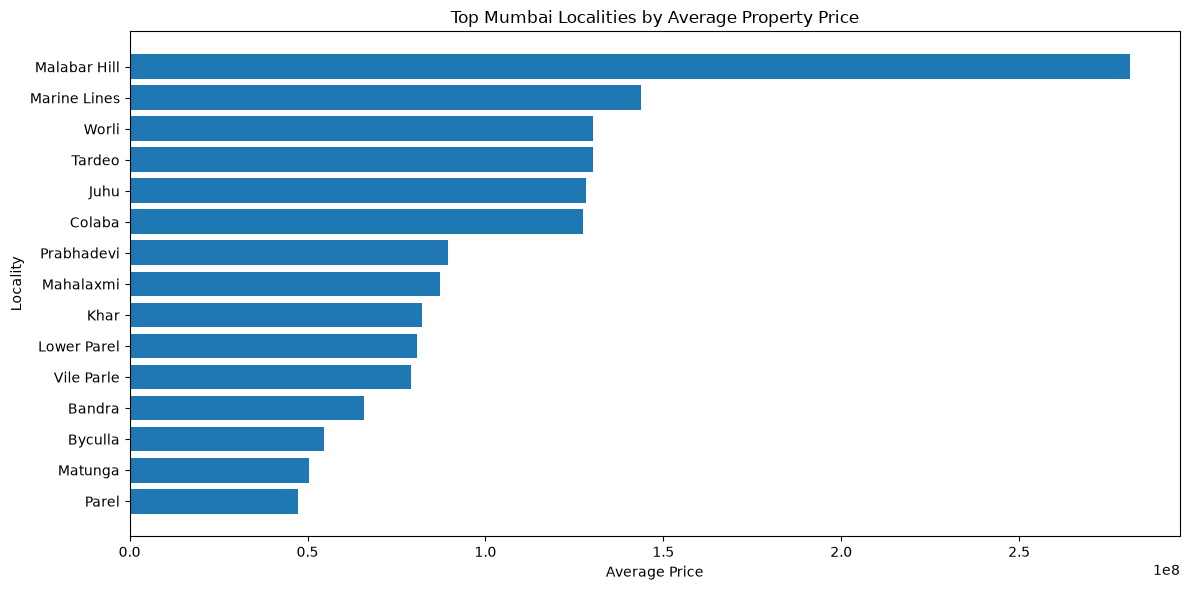

In [21]:
plt.figure(figsize=(12, 6))

plt.barh(
    top_expensive_localities["locality"],
    top_expensive_localities["average_price"]
)

plt.xlabel("Average Price")
plt.ylabel("Locality")
plt.title("Top Mumbai Localities by Average Property Price")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [22]:
top_ppsf_localities = (
    locality_stats_reliable
    .sort_values(
        "average_price_per_sqft",
        ascending=False
    )
    .head(15)
)

top_ppsf_localities

,locality,listing_count,average_price,median_price,average_price_per_sqft,average_predicted_price
192,Malabar Hill,36,2.811580e+08,122500000.0,76152.100253,2.641666e+08
359,Tardeo,76,1.302058e+08,90000000.0,59293.429308,1.328052e+08
66,Colaba,46,1.275570e+08,46000000.0,52237.309777,1.215658e+08
275,Prabhadevi,208,8.957243e+07,65000000.0,51853.293201,8.858611e+07
404,Worli,188,1.303466e+08,82082429.5,51566.333957,1.299819e+08
128,Juhu,179,1.283433e+08,100000000.0,51350.437902,1.260558e+08
188,Mahalaxmi,165,8.716537e+07,75000000.0,49787.340591,8.913362e+07
202,Marine Lines,33,1.437040e+08,75000000.0,47882.013298,1.481507e+08
184,Lower Parel,349,8.091012e+07,67064600.0,47436.605820,8.278096e+07
157,Khar,136,8.228774e+07,60732650.0,46716.150527,8.302996e+07


In [23]:
similarity_features = [
    "area",
    "bedroom_num",
    "bathroom_num",
    "balcony_num",
    "age",
    "total_floors",
    "latitude",
    "longitude"
]

similarity_data = df_intelligence[
    similarity_features
].copy()

print("Similarity features:")
print(similarity_features)

Similarity features:
['area', 'bedroom_num', 'bathroom_num', 'balcony_num', 'age', 'total_floors', 'latitude', 'longitude']


In [24]:
similarity_data = similarity_data.fillna(
    similarity_data.median(numeric_only=True)
)

print("Missing values after imputation:")
print(similarity_data.isnull().sum())

Missing values after imputation:
area            0
bedroom_num     0
bathroom_num    0
balcony_num     0
age             0
total_floors    0
latitude        0
longitude       0
dtype: int64


In [25]:
similarity_scaler = StandardScaler()

similarity_scaled = similarity_scaler.fit_transform(
    similarity_data
)

print("Similarity features scaled successfully")
print("Shape:", similarity_scaled.shape)

Similarity features scaled successfully
Shape: (51767, 8)


In [27]:
knn_model = NearestNeighbors(
    n_neighbors=11,
    metric="euclidean"
)

knn_model.fit(
    similarity_scaled
)

print("KNN similarity model created successfully")

KNN similarity model created successfully


In [28]:
def find_similar_properties(property_index, number_of_properties=5):
    
    distances, indices = knn_model.kneighbors(
        similarity_scaled[property_index].reshape(1, -1),
        n_neighbors=number_of_properties + 1
    )
    
    similar_indices = indices[0][1:]
    
    result = df_intelligence.iloc[
        similar_indices
    ].copy()
    
    result["similarity_distance"] = distances[0][1:]
    
    return result[
        [
            "locality",
            "property_type",
            "area",
            "bedroom_num",
            "bathroom_num",
            "age",
            "price",
            "predicted_price",
            "similarity_distance"
        ]
    ]


print("Similar property function created")

Similar property function created


In [29]:
similar_properties = find_similar_properties(
    property_index=0,
    number_of_properties=5
)

similar_properties

,locality,property_type,area,bedroom_num,bathroom_num,age,price,predicted_price,similarity_distance
16598,Kalyan,Apartment,750,2,2,0,5500000,6.067286e+06,0.010660
46196,Kalyan,Apartment,750,2,2,0,5100000,6.137814e+06,0.010705
16309,Kalyan,Apartment,775,2,2,0,3200000,4.238340e+06,0.027203
16712,Kalyan,Apartment,750,2,2,0,8200000,7.248056e+06,0.032062
9935,Kalyan,Apartment,765,2,2,0,4500000,7.232492e+06,0.032592


In [30]:
reference_property = df_intelligence.iloc[0]

print("REFERENCE PROPERTY")
print("=" * 50)

print("Locality:", reference_property["locality"])
print("Property Type:", reference_property["property_type"])
print("Area:", reference_property["area"])
print("Bedrooms:", reference_property["bedroom_num"])
print("Bathrooms:", reference_property["bathroom_num"])
print("Actual Price:", reference_property["price"])
print("Predicted Price:", reference_property["predicted_price"])

REFERENCE PROPERTY
Locality: Kalyan
Property Type: Apartment
Area: 757
Bedrooms: 2
Bathrooms: 2
Actual Price: 6600283
Predicted Price: 5749573.439304057


In [31]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [32]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 20 features:")

for feature in feature_names[:20]:
    print(feature)

Number of processed features: 112

First 20 features:
num__area
num__bedroom_num
num__bathroom_num
num__balcony_num
num__age
num__total_floors
num__latitude
num__longitude
num__area_per_bedroom
num__bathroom_per_bedroom
cat__locality_Agripada
cat__locality_Airoli
cat__locality_Ambernath
cat__locality_Andheri
cat__locality_Anjurdive
cat__locality_Badlapur
cat__locality_Bandra
cat__locality_Belapur
cat__locality_Bhandup
cat__locality_Bhayandar


In [33]:
shap_sample_size = min(
    30,
    X_processed.shape[0]
)

X_shap = X_processed[
    :shap_sample_size
]

if hasattr(X_shap, "toarray"):
    X_shap_dense = X_shap.toarray()
else:
    X_shap_dense = np.asarray(X_shap)

print("SHAP sample shape:", X_shap_dense.shape)

SHAP sample shape: (30, 112)


In [34]:
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

if isinstance(
    best_model,
    (RandomForestRegressor, GradientBoostingRegressor)
):
    
    shap_explainer = shap.TreeExplainer(
        best_model
    )
    
    shap_values = shap_explainer(
        X_shap_dense
    )
    
    print("TreeExplainer used")

else:
    
    shap_explainer = shap.Explainer(
        best_model,
        X_shap_dense
    )
    
    shap_values = shap_explainer(
        X_shap_dense
    )
    
    print("General SHAP Explainer used")

TreeExplainer used


In [35]:
shap_values_array = shap_values.values

mean_abs_shap = np.abs(
    shap_values_array
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean Absolute SHAP": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.head(20)

,Feature,Mean Absolute SHAP
0,num__bedroom_num,7.159876e+06
1,num__longitude,6.727683e+06
2,num__area,4.464777e+06
3,num__latitude,3.347377e+06
4,num__area_per_bedroom,6.839900e+05
5,num__balcony_num,2.487016e+05
6,num__age,1.514107e+05
7,cat__locality_Nerul,1.462117e+05
8,cat__locality_Kharghar,1.182658e+05
9,num__bathroom_num,1.149371e+05


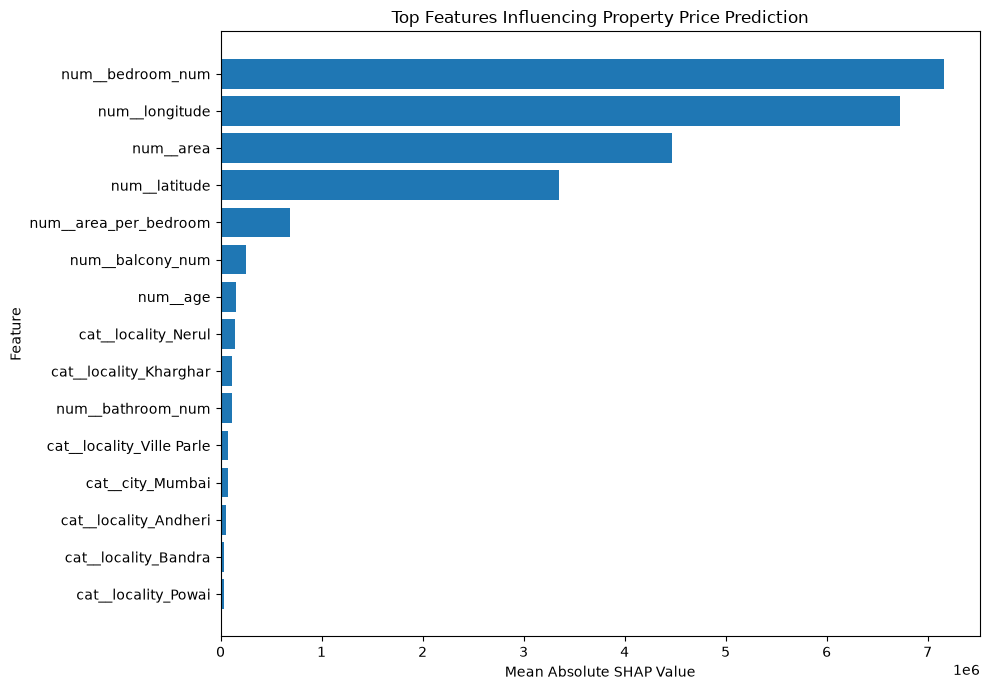

In [36]:
top_shap = shap_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_shap["Feature"].iloc[::-1],
    top_shap["Mean Absolute SHAP"].iloc[::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top Features Influencing Property Price Prediction")

plt.tight_layout()
plt.show()

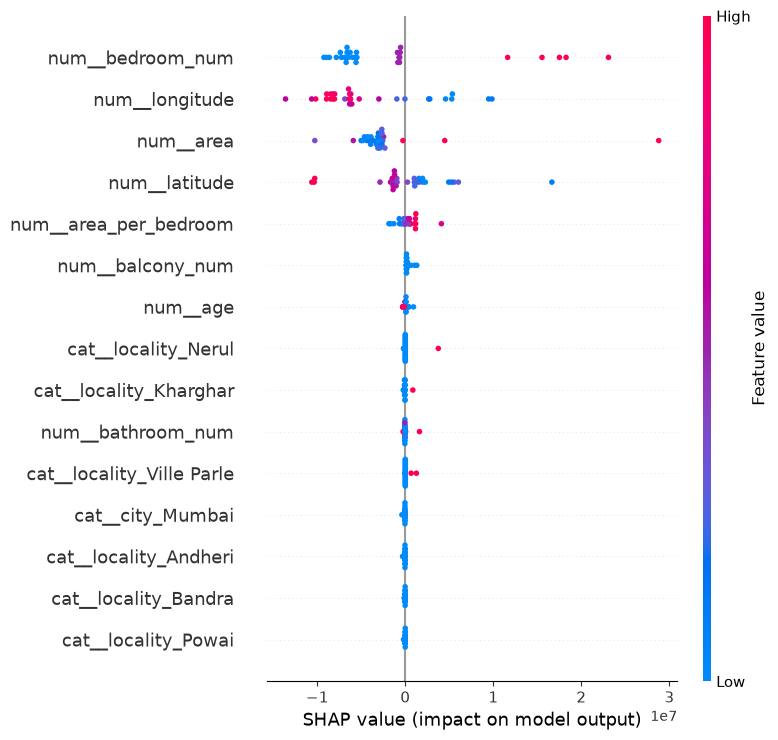

In [37]:
shap.summary_plot(
    shap_values_array,
    X_shap_dense,
    feature_names=feature_names,
    max_display=15
)

In [38]:
anomaly_features = [
    "price",
    "area",
    "price_per_sqft",
    "bedroom_num",
    "bathroom_num",
    "balcony_num",
    "age",
    "total_floors",
    "latitude",
    "longitude"
]

anomaly_data = df_intelligence[
    anomaly_features
].copy()

anomaly_data = anomaly_data.replace(
    [np.inf, -np.inf],
    np.nan
)

anomaly_data = anomaly_data.fillna(
    anomaly_data.median(numeric_only=True)
)

print("Anomaly data prepared")
print(anomaly_data.shape)

Anomaly data prepared
(51767, 10)


In [39]:
anomaly_scaler = StandardScaler()

anomaly_scaled = anomaly_scaler.fit_transform(
    anomaly_data
)

print("Anomaly features scaled successfully")

Anomaly features scaled successfully


In [40]:
isolation_model = IsolationForest(
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

isolation_model.fit(
    anomaly_scaled
)

print("Isolation Forest trained successfully")

Isolation Forest trained successfully


In [41]:
df_intelligence["anomaly_label"] = (
    isolation_model.predict(
        anomaly_scaled
    )
)

df_intelligence["anomaly_score"] = (
    isolation_model.decision_function(
        anomaly_scaled
    )
)

df_intelligence["is_anomaly"] = (
    df_intelligence["anomaly_label"] == -1
)

print(
    "Number of unusual records:",
    df_intelligence["is_anomaly"].sum()
)

print(
    "Percentage of unusual records:",
    round(
        df_intelligence["is_anomaly"].mean() * 100,
        2
    ),
    "%"
)

Number of unusual records: 518
Percentage of unusual records: 1.0 %


In [42]:
unusual_properties = df_intelligence[
    df_intelligence["is_anomaly"]
].copy()

unusual_properties[
    [
        "locality",
        "property_type",
        "area",
        "bedroom_num",
        "bathroom_num",
        "price",
        "price_per_sqft",
        "predicted_price",
        "anomaly_score"
    ]
].head(20)


,locality,property_type,area,bedroom_num,bathroom_num,price,price_per_sqft,predicted_price,anomaly_score
988,Juhu,Apartment,4500,4,5,225000000,50000.000000,2.415051e+08,-0.019565
990,Juhu,Apartment,3200,6,6,155000000,48437.500000,1.615710e+08,-0.030473
993,Juhu,Apartment,3200,5,5,175000000,54687.500000,1.693753e+08,-0.011510
1266,Santacruz,Apartment,3500,4,4,320000000,91428.571429,2.313325e+08,-0.023587
1270,Andheri,Apartment,2700,6,7,110000000,40740.740741,1.071704e+08,-0.018487
1351,Lower Parel,Apartment,3500,7,8,200000000,57142.857143,1.951421e+08,-0.071730
1385,Chembur,Villa,3800,5,4,100000000,26315.789474,1.049240e+08,-0.017147
1436,Chembur,Apartment,3874,5,5,165000000,42591.636551,1.506540e+08,-0.012603
1543,Vashi,Independent House,6000,8,6,110000000,18333.333333,1.186473e+08,-0.051266
1900,Chembur,Villa,3800,5,5,125100000,32921.052632,1.260644e+08,-0.024815


In [43]:
largest_price_differences = (
    df_intelligence
    .assign(
        absolute_difference=lambda x:
        x["price_difference"].abs()
    )
    .sort_values(
        "absolute_difference",
        ascending=False
    )
    .head(20)
)

largest_price_differences[
    [
        "locality",
        "property_type",
        "area",
        "price",
        "predicted_price",
        "price_difference",
        "price_difference_percent"
    ]
]

,locality,property_type,area,price,predicted_price,price_difference,price_difference_percent
35885,Juhu Scheme,Independent House,7700,800000000,3.726898e+08,4.273102e+08,114.655747
49867,Boisar,Independent House,7000,16005000,4.240185e+08,-4.080135e+08,-96.225401
21588,Marine Drive,Villa,4562,749181884,3.962870e+08,3.528949e+08,89.050329
36185,Malabar Hill,Apartment,24109,2147483647,1.842469e+09,3.050151e+08,16.554699
51485,Bandra Kurla Complex,Apartment,7875,585000000,3.011125e+08,2.838875e+08,94.279570
5070,Bandra,Apartment,2725,415800000,1.377347e+08,2.780653e+08,201.884711
28577,Bandra,Apartment,10894,220000000,4.796214e+08,-2.596214e+08,-54.130484
51758,Kandivali,Apartment,2437,706730000,4.664202e+08,2.403098e+08,51.522164
50747,Prabhadevi,Apartment,4334,540100000,3.079310e+08,2.321690e+08,75.396451
50748,Prabhadevi,Apartment,7398,924700000,7.031356e+08,2.215644e+08,31.510914


In [44]:
largest_percentage_differences = (
    df_intelligence
    .assign(
        absolute_percentage_difference=lambda x:
        x["price_difference_percent"].abs()
    )
    .sort_values(
        "absolute_percentage_difference",
        ascending=False
    )
    .head(20)
)

largest_percentage_differences[
    [
        "locality",
        "property_type",
        "area",
        "price",
        "predicted_price",
        "price_difference_percent"
    ]
]

,locality,property_type,area,price,predicted_price,price_difference_percent
21149,Thane,Apartment,1200,145000000,1.505818e+07,862.931657
30440,Goregaon,Apartment,780,142240000,1.589935e+07,794.627539
5070,Bandra,Apartment,2725,415800000,1.377347e+08,201.884711
21403,Thane,Apartment,1160,35000000,1.337242e+07,161.732796
4826,Koper Khairane,Apartment,350,11500000,4.467856e+06,157.394154
14492,Mahalaxmi,Apartment,2500,250000000,1.001316e+08,149.671491
35342,Versova,Apartment,349,8998000,3.634556e+06,147.568092
42526,Kalyan,Apartment,640,9500000,3.872740e+06,145.304332
47585,Nerul,Apartment,10000,360000000,1.499684e+08,140.050545
12662,Juhu,Villa,3000,380000000,1.625648e+08,133.752871


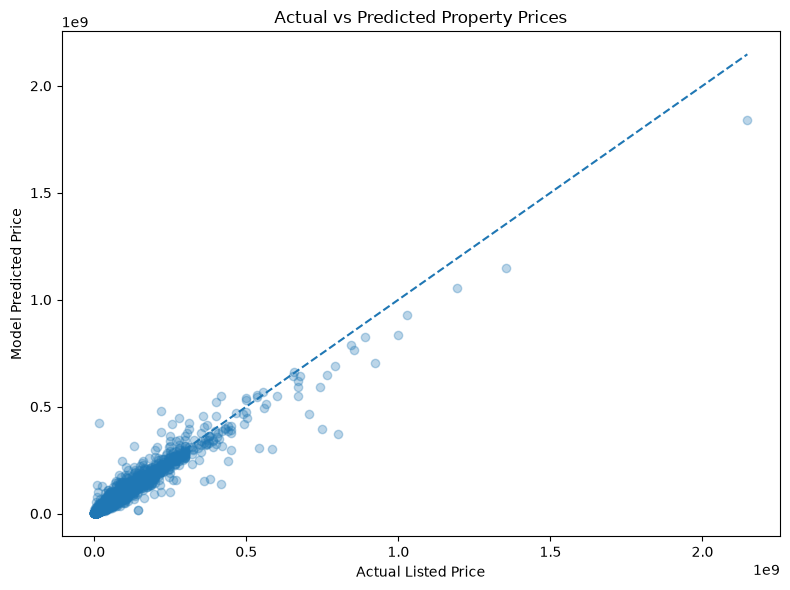

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df_intelligence["price"],
    df_intelligence["predicted_price"],
    alpha=0.3
)

min_value = min(
    df_intelligence["price"].min(),
    df_intelligence["predicted_price"].min()
)

max_value = max(
    df_intelligence["price"].max(),
    df_intelligence["predicted_price"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Listed Price")
plt.ylabel("Model Predicted Price")
plt.title("Actual vs Predicted Property Prices")

plt.tight_layout()
plt.show()

In [46]:
output_path = (
    "../data/processed/"
    "property_intelligence.csv"
)

df_intelligence.to_csv(
    output_path,
    index=False
)

print(
    "Property intelligence dataset saved:"
)

print(output_path)

Property intelligence dataset saved:
../data/processed/property_intelligence.csv


In [47]:
locality_output_path = (
    "../data/processed/"
    "locality_intelligence.csv"
)

locality_stats_reliable.to_csv(
    locality_output_path,
    index=False
)

print(
    "Locality intelligence saved:"
)

print(locality_output_path)

Locality intelligence saved:
../data/processed/locality_intelligence.csv


In [48]:
shap_output_path = (
    "../data/processed/"
    "shap_feature_importance.csv"
)

shap_importance.to_csv(
    shap_output_path,
    index=False
)

print(
    "SHAP feature importance saved:"
)

print(shap_output_path)

SHAP feature importance saved:
../data/processed/shap_feature_importance.csv


In [49]:
files_to_check = [
    "../data/processed/property_intelligence.csv",
    "../data/processed/locality_intelligence.csv",
    "../data/processed/shap_feature_importance.csv"
]

print("Checking saved files:\n")

for file in files_to_check:
    
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

Checking saved files:

✓ ../data/processed/property_intelligence.csv
✓ ../data/processed/locality_intelligence.csv
✓ ../data/processed/shap_feature_importance.csv


In [50]:
property_index = 0

property_data = df_intelligence.iloc[
    property_index
]

print("=" * 65)
print("PROPERTY INTELLIGENCE REPORT")
print("=" * 65)

print("\nPROPERTY DETAILS")
print("-" * 40)

print("Locality:", property_data["locality"])
print("Property Type:", property_data["property_type"])
print("Area:", property_data["area"])
print("Bedrooms:", property_data["bedroom_num"])
print("Bathrooms:", property_data["bathroom_num"])
print("Balconies:", property_data["balcony_num"])
print("Age:", property_data["age"])

print("\nPRICE ANALYSIS")
print("-" * 40)

print(
    "Listed Price:",
    property_data["price"]
)

print(
    "Predicted Price:",
    round(property_data["predicted_price"], 2)
)

print(
    "Difference:",
    round(property_data["price_difference"], 2)
)

print(
    "Difference %:",
    round(
        property_data["price_difference_percent"],
        2
    ),
    "%"
)

print("\nANOMALY STATUS")
print("-" * 40)

if property_data["is_anomaly"]:
    print("Statistically unusual property record")
else:
    print("No statistical anomaly detected")

PROPERTY INTELLIGENCE REPORT

PROPERTY DETAILS
----------------------------------------
Locality: Kalyan
Property Type: Apartment
Area: 757
Bedrooms: 2
Bathrooms: 2
Balconies: 0
Age: 0

PRICE ANALYSIS
----------------------------------------
Listed Price: 6600283
Predicted Price: 5749573.44
Difference: 850709.56
Difference %: 14.8 %

ANOMALY STATUS
----------------------------------------
No statistical anomaly detected


In [51]:
print("SIMILAR PROPERTIES")
print("=" * 65)

find_similar_properties(
    property_index=property_index,
    number_of_properties=5
)

SIMILAR PROPERTIES


,locality,property_type,area,bedroom_num,bathroom_num,age,price,predicted_price,similarity_distance
16598,Kalyan,Apartment,750,2,2,0,5500000,6.067286e+06,0.010660
46196,Kalyan,Apartment,750,2,2,0,5100000,6.137814e+06,0.010705
16309,Kalyan,Apartment,775,2,2,0,3200000,4.238340e+06,0.027203
16712,Kalyan,Apartment,750,2,2,0,8200000,7.248056e+06,0.032062
9935,Kalyan,Apartment,765,2,2,0,4500000,7.232492e+06,0.032592


In [52]:
print("=" * 70)
print("PROPERTY INTELLIGENCE SYSTEM COMPLETED")
print("=" * 70)

print("\nFeatures implemented:")

print("1. Property price prediction")
print("2. Predicted price per square foot")
print("3. Listed vs predicted price comparison")
print("4. Locality-level market intelligence")
print("5. Similar property discovery using KNN")
print("6. SHAP model explainability")
print("7. Statistical anomaly detection")
print("8. Actual vs predicted price visualization")

print("\nGenerated files:")

print("- property_intelligence.csv")
print("- locality_intelligence.csv")
print("- shap_feature_importance.csv")

print("\nProperty Intelligence stage completed successfully.")

PROPERTY INTELLIGENCE SYSTEM COMPLETED

Features implemented:
1. Property price prediction
2. Predicted price per square foot
3. Listed vs predicted price comparison
4. Locality-level market intelligence
5. Similar property discovery using KNN
6. SHAP model explainability
7. Statistical anomaly detection
8. Actual vs predicted price visualization

Generated files:
- property_intelligence.csv
- locality_intelligence.csv
- shap_feature_importance.csv

Property Intelligence stage completed successfully.
